In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('placementdata.csv')

In [3]:
df

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed


In [7]:
encoder = LabelEncoder()
elements = ["ExtracurricularActivities", "PlacementTraining", "PlacementStatus"]
for element in elements:
    df[element] = encoder.fit_transform(df[element])

In [8]:
df.shape

(10000, 12)

In [9]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  int64  
 8   PlacementTraining          10000 non-null  int64  
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [11]:
df.drop(columns=['StudentID'], inplace=True)

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(72)

In [14]:
df.drop_duplicates(inplace=True)

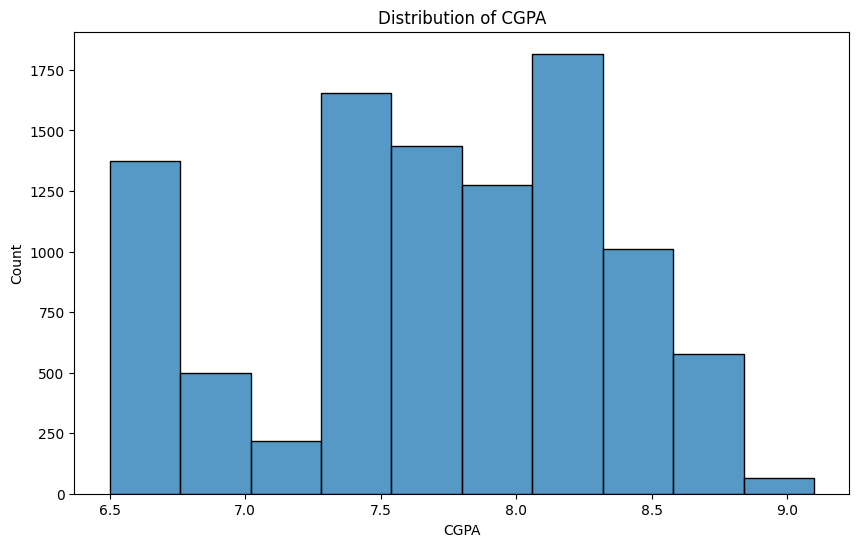

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(x='CGPA', data = df, bins=10)
plt.title('Distribution of CGPA')
plt.xlabel('CGPA')
plt.ylabel('Count')
plt.show()

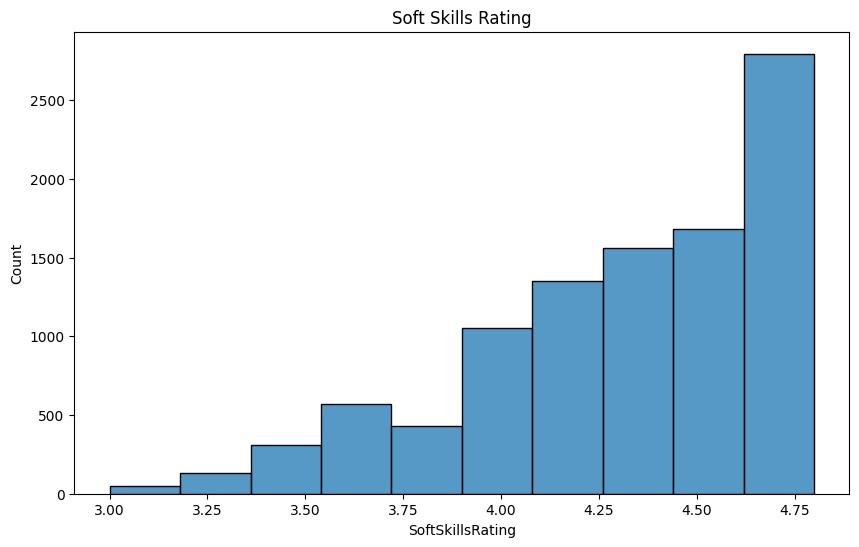

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(x='SoftSkillsRating', data = df, bins=10)
plt.title('Soft Skills Rating')
plt.show()

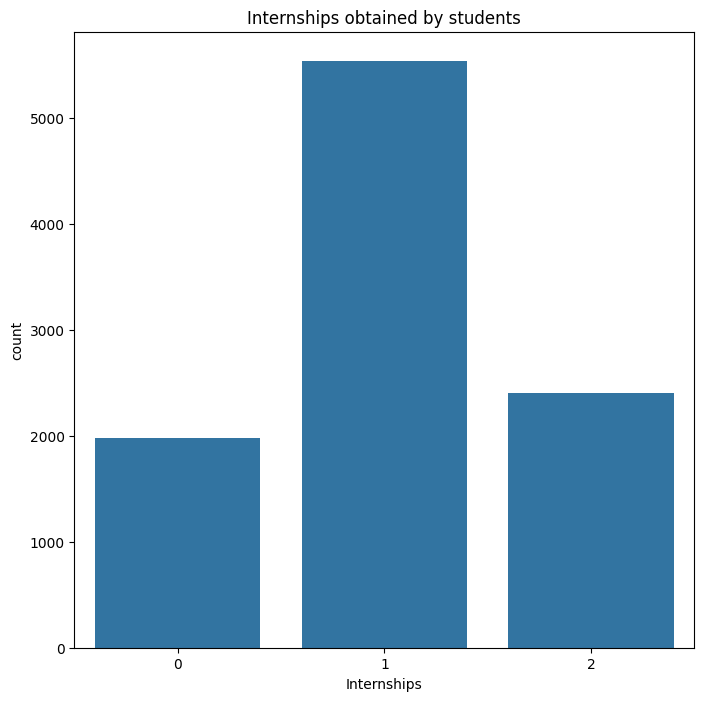

In [22]:
plt.figure(figsize=(8, 8))
sns.countplot(x='Internships', data=df)
plt.title('Internships obtained by students')
plt.show()

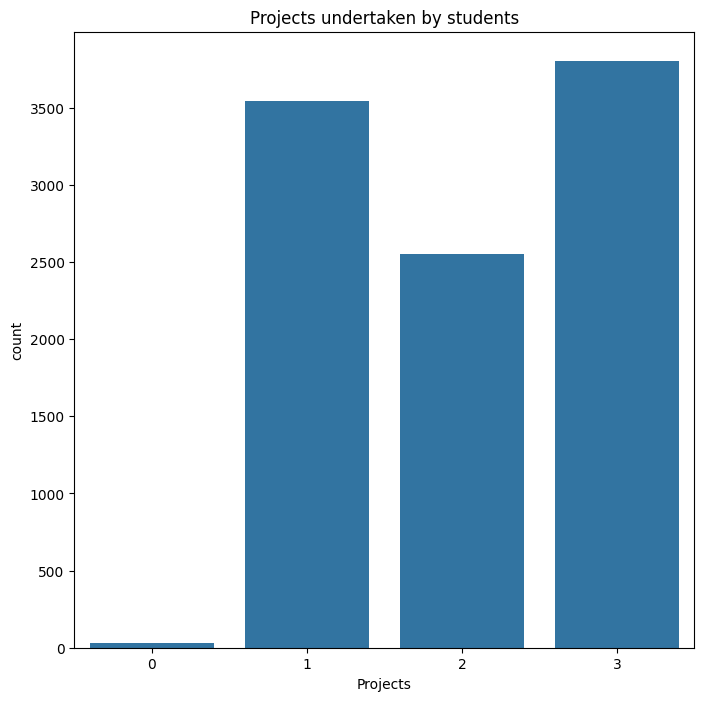

In [23]:
plt.figure(figsize=(8, 8))
sns.countplot(x='Projects', data=df)
plt.title('Projects undertaken by students')
plt.show()

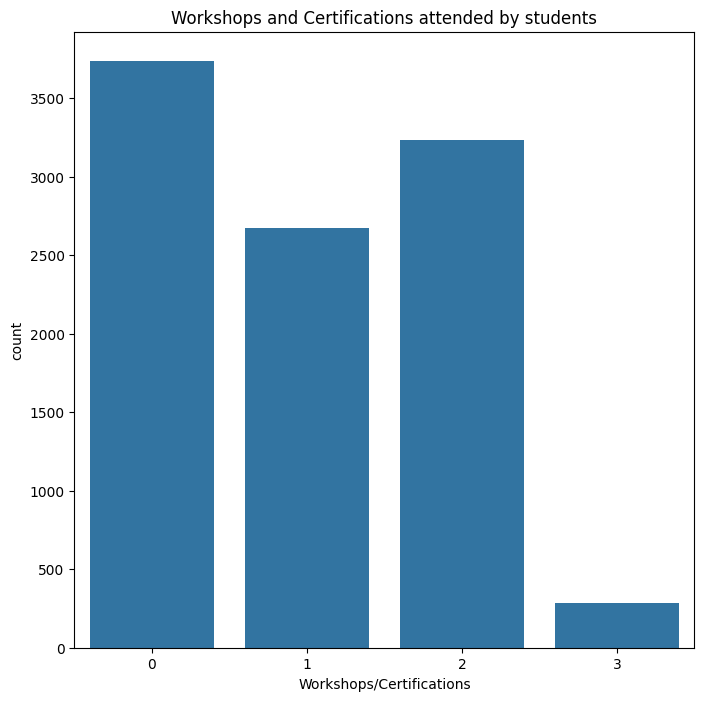

In [24]:
plt.figure(figsize=(8, 8))
sns.countplot(x='Workshops/Certifications', data=df)
plt.title('Workshops and Certifications attended by students')
plt.show()

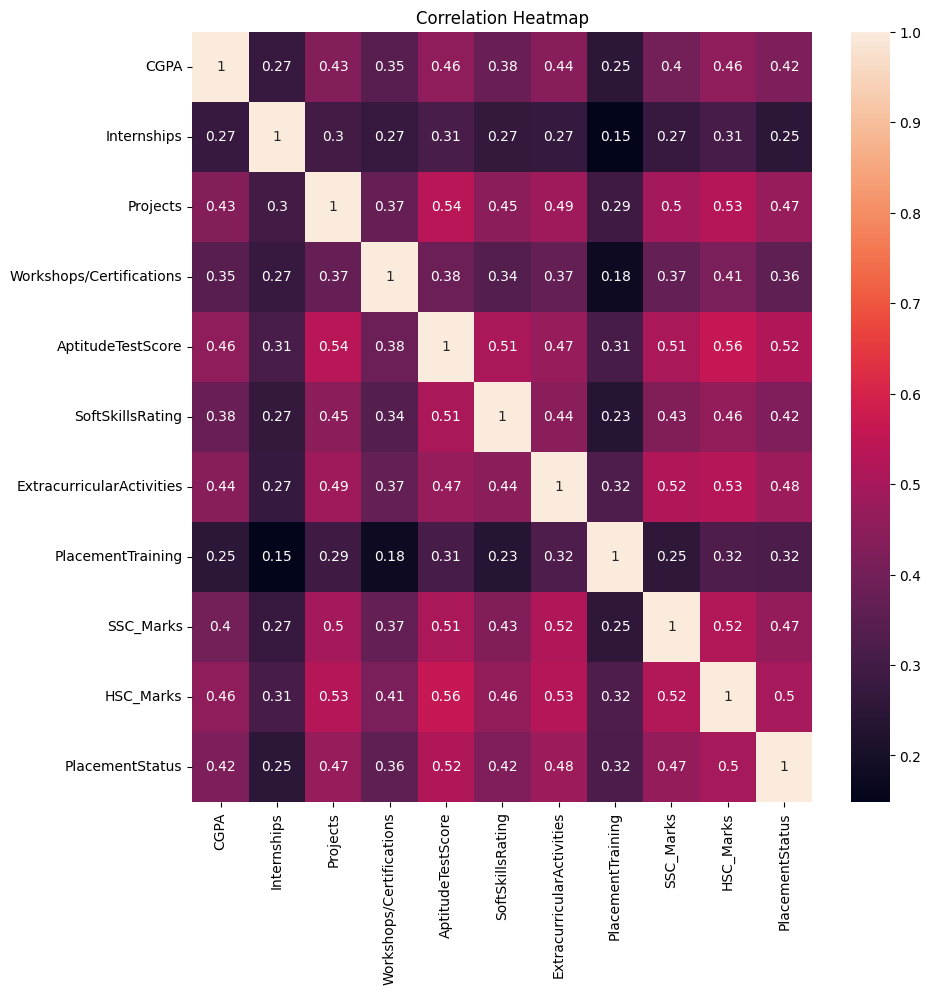

In [25]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [29]:
X = df.drop('PlacementStatus', axis=1)
y = df['PlacementStatus']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [37]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, classification_report, r2_score

In [44]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy*100:.2f}')

Accuracy: 80.31


In [45]:
report = classification_report(y_test, y_pred)
print('Classification Report:',report)

Classification Report:               precision    recall  f1-score   support

           0       0.85      0.81      0.83      1188
           1       0.74      0.79      0.76       798

    accuracy                           0.80      1986
   macro avg       0.80      0.80      0.80      1986
weighted avg       0.81      0.80      0.80      1986



In [46]:
print(f"train_score: {model.score(X_train, y_train)*100:.2f}")
print(f"test_score: {model.score(X_test, y_test)*100:.2f}")

train_score: 79.72
test_score: 80.31
